# DNATCO → graph → ML, end to end

A short demo of the pipeline:

1. **fetch** DNATCO "extended" mmCIFs for a set of PDB ids (`dnatco_fetch.py`)
2. **convert** each to an rnaglib-format 2.5D graph JSON (`dnatco_to_graph.py`)
3. **train** a Relational GCN to **predict the interaction type of base pairs** (`train_pair_interactions.py`)

We use a small sample here; for the real run just raise `N_STRUCTURES` (e.g. 1000).

**The task (edge classification):** for every annotated base pair, predict its
Leontis–Westhof family (cWW, tWS, cSH, …). To avoid leakage, the model is told
*which* residues pair (one generic `PAIR` relation) + backbone + nucleotide
identities, and must recover the *geometry* class. cWW dominates (~75%), so we
also track accuracy on the **non-canonical** pairs — the WS2-relevant signal.

In [1]:
# auto-reload edited .py modules so kernel picks up script changes without a restart
%load_ext autoreload
%autoreload 2

import concurrent.futures as cf
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import torch

from dnatco_fetch import rcsb_rna_ids, fetch_one
from dnatco_to_graph import dnatco_cif_to_graph
from train_pair_interactions import load_dataset, PairRGCN, run_epoch
from rnaglib.utils import dump_json

N_STRUCTURES = 1000           # bump to 1000 for the full run
CIFS = Path("demo/cifs"); CIFS.mkdir(parents=True, exist_ok=True)
GRAPHS = Path("demo/graphs"); GRAPHS.mkdir(parents=True, exist_ok=True)

/Users/cw_liao/na-hackathon-2026/workstreams/ws1-annotation-validation/mmcif-to-pyg/.pixi/envs/default/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Fetch DNATCO mmCIFs

In [2]:
ids = rcsb_rna_ids(N_STRUCTURES)            # PDB ids of RNA-containing entries
with cf.ThreadPoolExecutor(max_workers=8) as ex:
    results = list(ex.map(lambda p: fetch_one(p, CIFS, False), ids))
print("fetch status:", dict(Counter(s.split('_')[0] for _, s in results)))
print("cif files on disk:", len(list(CIFS.glob('*.cif'))))

fetch status: {'skip': 972, 'http': 28}
cif files on disk: 972


## 2. Convert to graph JSON

In [3]:
ok = 0
for cif in sorted(CIFS.glob('*.cif')):
    try:
        G = dnatco_cif_to_graph(cif)
        if G.number_of_nodes():
            dump_json(str(GRAPHS / f'{cif.stem}.json'), G)
            ok += 1
    except Exception as e:
        print(cif.name, 'failed:', e)
print(f'wrote {ok} graphs')

# peek at one graph
G = dnatco_cif_to_graph(next(CIFS.glob('*.cif')))
lw = Counter(d['LW'] for *_, d in G.edges(data=True))
print('example graph:', G.graph['pdbid'], '| nodes', G.number_of_nodes(),
      '| edge types', dict(lw))

wrote 972 graphs
example graph: 2du5 | nodes 1139 | edge types {'B53': 1136, 'B35': 1136, 'cWW': 34}


## 3. Train the RGCN to classify base-pair interactions

For each base pair, predict its Leontis–Westhof family (18-way multi-class).

Because cWW is ~75% of pairs, plain (micro) accuracy is misleading. We report the
**honest, imbalance-aware metrics**:
- **micro acc** — overall fraction correct (inflated by cWW)
- **balanced acc** — mean per-class recall (each LW family weighted equally)
- **macro-F1** — mean per-class F1
- **non-canonical recall** — recall on everything except cWW (the WS2 signal)

In [4]:
data_list, lw_vocab = load_dataset(GRAPHS)
gen = torch.Generator().manual_seed(0)
perm = torch.randperm(len(data_list), generator=gen).tolist()
n_val = max(1, len(data_list) // 5)
val = [data_list[i] for i in perm[:n_val]]
train = [data_list[i] for i in perm[n_val:]] or val

counts = Counter()
for d in train:
    counts.update(d.pair_y.tolist())
baseline = max(counts.values()) / sum(counts.values())   # majority (micro) baseline

model = PairRGCN(num_classes=len(lw_vocab))
model._canon_idx = lw_vocab.get('cWW')      # lets run_epoch compute non-canonical recall
opt = torch.optim.Adam(model.parameters(), lr=1e-2)

hist = []
for epoch in range(1, 31):
    run_epoch(model, train, train=True, optimizer=opt, batch_size=32, gen=gen, device='cpu')
    va = run_epoch(model, val, train=False, optimizer=opt, batch_size=32, gen=gen, device='cpu')
    hist.append((epoch, va['micro_acc'], va['balanced_acc'], va['macro_f1'], va['noncanonical_recall']))
    print(f"epoch {epoch:2d}  micro {va['micro_acc']:.3f}  balanced {va['balanced_acc']:.3f}  "
          f"macro-F1 {va['macro_f1']:.3f}  non-canon {va['noncanonical_recall']:.3f}")
print(f"\n{len(data_list)} graphs | {len(lw_vocab)} LW classes | majority baseline {baseline:.3f}")

epoch  1  micro 0.739  balanced 0.056  macro-F1 0.047  non-canon 0.000
epoch  2  micro 0.819  balanced 0.253  macro-F1 0.237  non-canon 0.377
epoch  3  micro 0.851  balanced 0.295  macro-F1 0.304  non-canon 0.466
epoch  4  micro 0.872  balanced 0.396  macro-F1 0.391  non-canon 0.557
epoch  5  micro 0.886  balanced 0.461  macro-F1 0.456  non-canon 0.603
epoch  6  micro 0.905  balanced 0.545  macro-F1 0.556  non-canon 0.682
epoch  7  micro 0.919  balanced 0.598  macro-F1 0.648  non-canon 0.707
epoch  8  micro 0.933  balanced 0.698  macro-F1 0.700  non-canon 0.792
epoch  9  micro 0.943  balanced 0.734  macro-F1 0.767  non-canon 0.806
epoch 10  micro 0.951  balanced 0.786  macro-F1 0.810  non-canon 0.846
epoch 11  micro 0.958  balanced 0.797  macro-F1 0.831  non-canon 0.854
epoch 12  micro 0.961  balanced 0.821  macro-F1 0.841  non-canon 0.877
epoch 13  micro 0.964  balanced 0.839  macro-F1 0.865  non-canon 0.877
epoch 14  micro 0.966  balanced 0.836  macro-F1 0.869  non-canon 0.883
epoch 

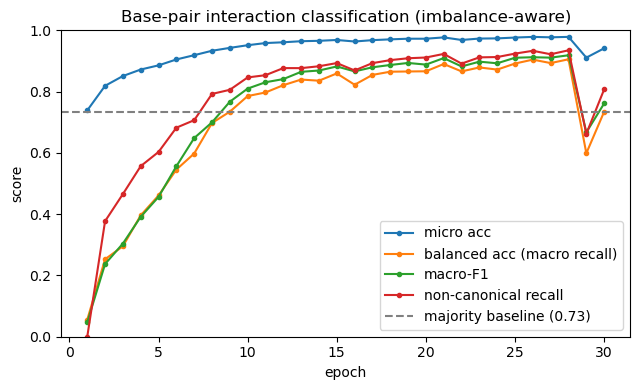

In [5]:
ep, micro, bal, f1, nc = zip(*hist)
plt.figure(figsize=(6.5, 4))
plt.plot(ep, micro, '-o', ms=3, label='micro acc')
plt.plot(ep, bal, '-o', ms=3, label='balanced acc (macro recall)')
plt.plot(ep, f1, '-o', ms=3, label='macro-F1')
plt.plot(ep, nc, '-o', ms=3, label='non-canonical recall')
plt.axhline(baseline, ls='--', c='gray', label=f'majority baseline ({baseline:.2f})')
plt.xlabel('epoch'); plt.ylabel('score'); plt.ylim(0, 1)
plt.legend(); plt.title('Base-pair interaction classification (imbalance-aware)')
plt.tight_layout(); plt.show()

## 4. Predict which residues pair — and does geometry help? (ablation)

A second task (`train_contact_prediction.py`): for a pair of nucleotides, predict
whether they **base-pair** (contact / link prediction), using the experimental
geometry now stored in the graphs (`xyz_C1p`/`xyz_glyN`/`xyz_P`).

- message passing: **backbone only** (base-pair edges are the labels, so they're hidden)
- geometry as rotation/translation-invariant features: C1′–C1′, glyN–glyN, P–P distances + seq separation
- **hard negatives**: spatially-close non-pairs (via KD-tree), so distance alone can't solve it

**Ablation:** we train the *same* model twice — **with** vs **without** the geometric
features — and compare to a distance-only baseline (pair iff C1′–C1′ ≤ 12.5 Å). This
shows whether the experimental coordinates actually help the model learn.

In [6]:
import train_contact_prediction as cp   # separate module; avoids name clashes with section 3

# graphs must contain coordinates (section 2 includes them by default)
cdata = cp.load_dataset(GRAPHS, neg_ratio=1.0, cutoff=18.0, seed=0)
assert cdata, "No coord-bearing graphs found — re-run section 2 so graphs include coordinates."

cgen = torch.Generator().manual_seed(0)
cperm = torch.randperm(len(cdata), generator=cgen).tolist()
cnv = max(1, len(cdata) // 5)
cval = [cdata[i] for i in cperm[:cnv]]
ctrain = [cdata[i] for i in cperm[cnv:]] or cval

base = cp.distance_baseline(cval)   # predict pair iff C1'-C1' <= 12.5 A
print(f"distance-only baseline:  F1 {base['f1']:.3f}  (P {base['precision']:.3f}  R {base['recall']:.3f})\n")

# ablation: identical setup, only toggle the geometric features
curves = {}
for use_geom in (True, False):
    g = torch.Generator().manual_seed(0)            # same data order/sampling for a fair comparison
    cmodel = cp.ContactGNN(use_geom=use_geom)
    copt = torch.optim.Adam(cmodel.parameters(), lr=5e-3)
    f1s = []
    for epoch in range(1, 21):
        cp.run_epoch(cmodel, ctrain, train=True, optimizer=copt, batch_size=16, gen=g, device='cpu')
        m = cp.run_epoch(cmodel, cval, train=False, optimizer=copt, batch_size=16, gen=g, device='cpu')
        f1s.append(m['f1'])
    curves[use_geom] = f1s
    print(f"{'with geometry' if use_geom else 'no geometry (seq+backbone)':28s} final F1 {f1s[-1]:.3f}")

print(f"\ngeometry gives +{curves[True][-1] - curves[False][-1]:.3f} F1 over sequence+backbone only")

[contact] skipped 76 graphs (no coords or no pairs)


distance-only baseline:  F1 0.842  (P 0.737  R 0.983)

with geometry                final F1 0.958
no geometry (seq+backbone)   final F1 0.886

geometry gives +0.072 F1 over sequence+backbone only


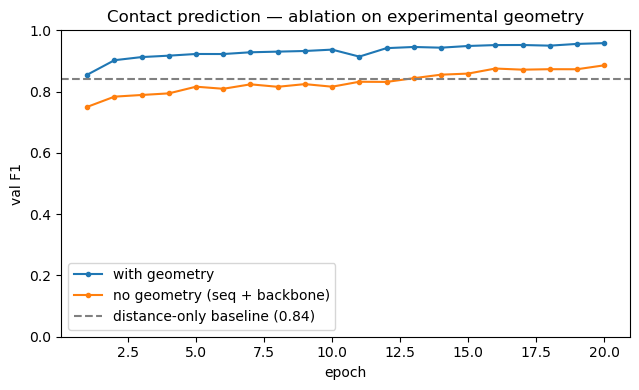

In [7]:
import matplotlib.pyplot as plt
plt.figure(figsize=(6.5, 4))
epochs = range(1, len(curves[True]) + 1)
plt.plot(epochs, curves[True], '-o', ms=3, label='with geometry')
plt.plot(epochs, curves[False], '-o', ms=3, label='no geometry (seq + backbone)')
plt.axhline(base['f1'], ls='--', c='gray', label=f"distance-only baseline ({base['f1']:.2f})")
plt.xlabel('epoch'); plt.ylabel('val F1'); plt.ylim(0, 1)
plt.legend(); plt.title('Contact prediction — ablation on experimental geometry')
plt.tight_layout(); plt.show()

## 5. Detect *and* type base pairs — per-class performance + a test example

The unified model (`train_pair_detect_type.py`): for each candidate pair predict
one of **NONE / cWW / tWS / cSH / …** — i.e. find the pairs **and** name their
Leontis–Westhof family in one shot (backbone + geometry as input, base-pair edges hidden).

Below we:
1. train it and report **detection F1**, **exact (detect+type)** accuracy, and **typing | detected**,
2. plot **per-class** precision/recall/F1 (with support `n`) on the test split — exposing how the rare families fare vs cWW,
3. show **one test structure**: a table of its base pairs (true vs predicted family) and an arc diagram — true pairs above (green = type correct, red = missed/mistyped), false positives below (orange dotted).

In [8]:
import train_pair_detect_type as dt   # joint detect + type model

ddata, class_names, dfiles = dt.load_dataset(GRAPHS, neg_ratio=1.0, cutoff=18.0, seed=0)
dgen = torch.Generator().manual_seed(0)
dperm = torch.randperm(len(ddata), generator=dgen).tolist()
dnv = max(1, len(ddata) // 5)
dval = [ddata[i] for i in dperm[:dnv]]
dval_files = [dfiles[i] for i in dperm[:dnv]]
dtrain = [ddata[i] for i in dperm[dnv:]] or dval

dmodel = dt.PairTypeGNN(num_classes=len(class_names))
dopt = torch.optim.Adam(dmodel.parameters(), lr=5e-3)
for epoch in range(1, 16):
    dt.run_epoch(dmodel, dtrain, train=True, optimizer=dopt, batch_size=16, gen=dgen, device='cpu')
m = dt.run_epoch(dmodel, dval, train=False, optimizer=dopt, batch_size=16, gen=dgen, device='cpu')

print(f"{len(ddata)} graphs | {len(class_names)} classes (NONE + {len(class_names) - 1} LW families)")
print(f"detection F1 {m['det_F1']:.3f}  |  exact (detect+type) {m['exact_acc']:.3f}  "
      f"|  typing | detected {m['type_acc_given_detected']:.3f}")
conf = dt.confusion(dmodel, dval)   # confusion matrix on the test split, for the per-class plot below

[detect+type] skipped 76 graphs (no coords or no pairs)


896 graphs | 19 classes (NONE + 18 LW families)
detection F1 0.933  |  exact (detect+type) 0.901  |  typing | detected 0.968


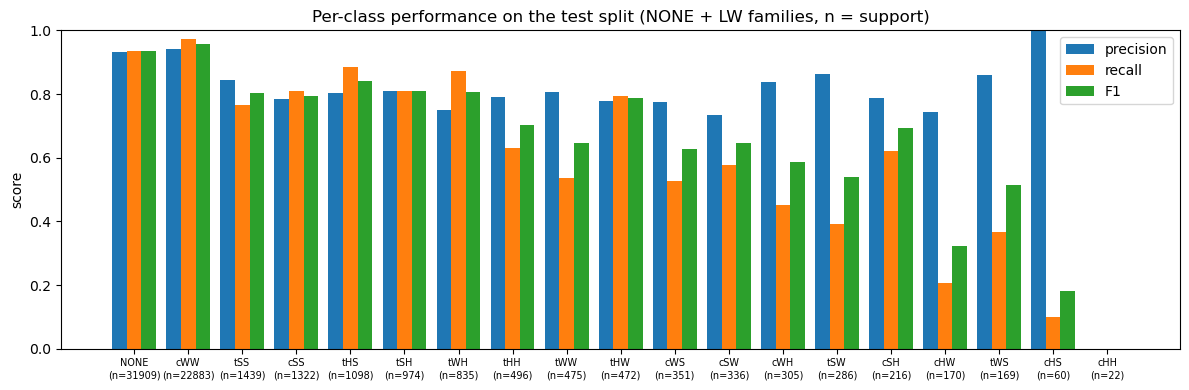

In [9]:
import numpy as np
prec, rec, f1, sup = dt.per_class_prf(conf)
order = [i for i in np.argsort(-sup.numpy()) if sup[i] > 0]   # classes present in val, by support
xs = np.arange(len(order)); w = 0.27
plt.figure(figsize=(12, 4))
plt.bar(xs - w, prec.numpy()[order], w, label='precision')
plt.bar(xs,     rec.numpy()[order],  w, label='recall')
plt.bar(xs + w, f1.numpy()[order],   w, label='F1')
plt.xticks(xs, [f"{class_names[i]}\n(n={int(sup[i])})" for i in order], fontsize=7)
plt.ylabel('score'); plt.ylim(0, 1); plt.legend()
plt.title('Per-class performance on the test split (NONE + LW families, n = support)')
plt.tight_layout(); plt.show()

Example 2a9l: 38 nt, 14 true pairs, 28 candidate pairs scored


,pair,true,pred,ok
14,A6-U33,cWW,cWW,OK
15,C10-G26,cWW,cWW,OK
16,C17-G22,cWW,cWW,OK
17,C7-G29,cWW,cWW,OK
18,C9-G27,cWW,cWW,OK
19,G1-C38,cWW,cWW,OK
20,G14-C25,cWW,cWW,OK
21,G15-C24,cWW,cWW,OK
22,G2-C37,cWW,cWW,OK
23,G3-C36,cWW,cWW,OK


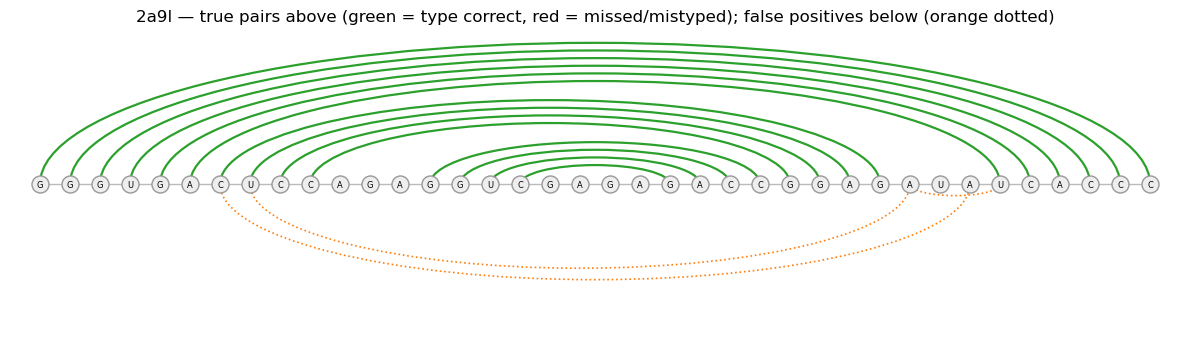

In [10]:
import numpy as np, pandas as pd
from matplotlib.patches import Arc
from IPython.display import display

# choose a *representative* single-chain test structure: enough pairs, detection recall
# closest to the median (not the best or worst case)
cands = []
for k in range(len(dval)):
    _, lab, ch, _ = dt.graph_node_order(dval_files[k])
    if len(set(ch)) == 1 and 10 <= len(lab) <= 90 and int(dval[k].pair_y.gt(0).sum()) >= 5:
        pk = dt.predict_one(dmodel, dval[k]); pos = dval[k].pair_y > 0
        cands.append((float((pk[pos] > 0).sum()) / int(pos.sum()), k))   # detection recall
cands.sort()
ex = cands[len(cands) // 2][1] if cands else 0

pid, labels, chains, seqs = dt.graph_node_order(dval_files[ex])
pred = dt.predict_one(dmodel, dval[ex])
pi = dval[ex].pair_index.numpy(); y = dval[ex].pair_y.numpy()

rows = [{"pair": f"{labels[pi[0, c]]}-{labels[pi[1, c]]}",
         "true": class_names[int(y[c])], "pred": class_names[int(pred[c])],
         "ok": "OK" if y[c] == pred[c] else "x"} for c in range(pi.shape[1])]
df = pd.DataFrame(rows).sort_values(["true", "pair"]).reset_index(drop=True)
print(f"Example {pid}: {len(labels)} nt, {int((y > 0).sum())} true pairs, {len(y)} candidate pairs scored")
display(df[df.true != "NONE"].head(20))          # the real base pairs and how the model called them

# arc diagram: true pairs above (green=type correct, red=missed/mistyped); false positives below
xpos = {i: k for k, i in enumerate(sorted(range(len(labels)), key=lambda i: seqs[i]))}
fig, ax = plt.subplots(figsize=(12, 3.6))
ax.plot([0, len(labels) - 1], [0, 0], color="#bbb", lw=1, zorder=0)
for i in range(len(labels)):
    ax.scatter([xpos[i]], [0], s=150, color="#eee", edgecolors="#999", zorder=3)
    ax.text(xpos[i], 0, labels[i][0], ha="center", va="center", fontsize=6, zorder=4)
for c in range(pi.shape[1]):
    a, b = sorted((xpos[pi[0, c]], xpos[pi[1, c]])); w = b - a; t, p = int(y[c]), int(pred[c])
    if t > 0:
        ax.add_patch(Arc(((a + b) / 2, 0), w, w * 0.6, theta1=0, theta2=180,
                         color="#2ca02c" if t == p else "#d62728", lw=1.6, zorder=2))
    elif p > 0:
        ax.add_patch(Arc(((a + b) / 2, 0), w, w * 0.6, theta1=180, theta2=360,
                         color="#ff7f0e", lw=1.2, ls=":", zorder=2))
ax.set_xlim(-1, len(labels)); ax.set_ylim(-len(labels) * 0.32, len(labels) * 0.32); ax.axis("off")
ax.set_title(f"{pid} — true pairs above (green = type correct, red = missed/mistyped); "
             f"false positives below (orange dotted)")
plt.tight_layout(); plt.show()

## 6. Actual performance on an independent test set (RS25, unseen structures)

The Section 5 numbers are an internal split of the demo set. For a fair estimate of
**real-world performance**, we evaluate the trained model on **RS25**
(`data/RS25_RNA_c2.csv`) — a curated RNA set — using only the structures whose PDB id
**was not in the demo training set** (overlapping ids are excluded).

We fetch + convert RS25 the same way (DNATCO → graph, coordinates included), encode it
against the **same class vocabulary** the model was trained with, then report detection
F1 / exact / typing and per-class performance on the held-out structures. Closeness to
the Section 5 val numbers indicates how well the model generalizes.

In [11]:
import csv

# build the RS25 dataset (fetch + convert; both steps skip files already present)
RS25_CSV = Path("../../../data/RS25_RNA_c2.csv")
RS25_CIFS = Path("rs25/cifs"); RS25_CIFS.mkdir(parents=True, exist_ok=True)
RS25_GRAPHS = Path("rs25/graphs"); RS25_GRAPHS.mkdir(parents=True, exist_ok=True)

rs_ids = sorted({r[0].strip().lower() for r in csv.reader(open(RS25_CSV)) if r and r[0].strip()})
with cf.ThreadPoolExecutor(max_workers=12) as exr:
    list(exr.map(lambda p: fetch_one(p, RS25_CIFS, False), rs_ids))
for cif in sorted(RS25_CIFS.glob('*.cif')):
    out = RS25_GRAPHS / f'{cif.stem}.json'
    if out.exists():
        continue
    try:
        Gx = dnatco_cif_to_graph(cif)
        if Gx.number_of_nodes():
            dump_json(str(out), Gx)
    except Exception:
        pass
print(f"RS25: {len(rs_ids)} ids -> {len(list(RS25_GRAPHS.glob('*.json')))} graphs")

# held-out = RS25 structures whose PDB id was NOT in the demo set used for training,
# encoded against the SAME class vocabulary the model was trained with
seen = {f.stem for f in dfiles}
rdata, _, rfiles = dt.load_dataset(RS25_GRAPHS, seed=0, class_names=class_names)
held = [rdata[i] for i in range(len(rdata)) if rfiles[i].stem not in seen]
print(f"RS25 graphs {len(rdata)} | overlap with demo (excluded) {len(rdata) - len(held)} | held-out test {len(held)}")

conf_rs25 = dt.confusion(dmodel, held)
mh = dt.metrics_from_confusion(conf_rs25)
print(f"\nHELD-OUT RS25 ({len(held)} unseen structures):")
print(f"  detection F1 {mh['det_F1']:.3f}  |  exact (detect+type) {mh['exact_acc']:.3f}  "
      f"|  typing | detected {mh['type_acc_given_detected']:.3f}")
print(f"  (in-distribution val for reference: detF1 {m['det_F1']:.3f}, exact {m['exact_acc']:.3f})")

RS25: 738 ids -> 738 graphs
RS25 graphs 639 | overlap with demo (excluded) 73 | held-out test 566

HELD-OUT RS25 (566 unseen structures):
  detection F1 0.909  |  exact (detect+type) 0.852  |  typing | detected 0.958
  (in-distribution val for reference: detF1 0.933, exact 0.901)


[detect+type] skipped 99 graphs (no coords or no pairs)


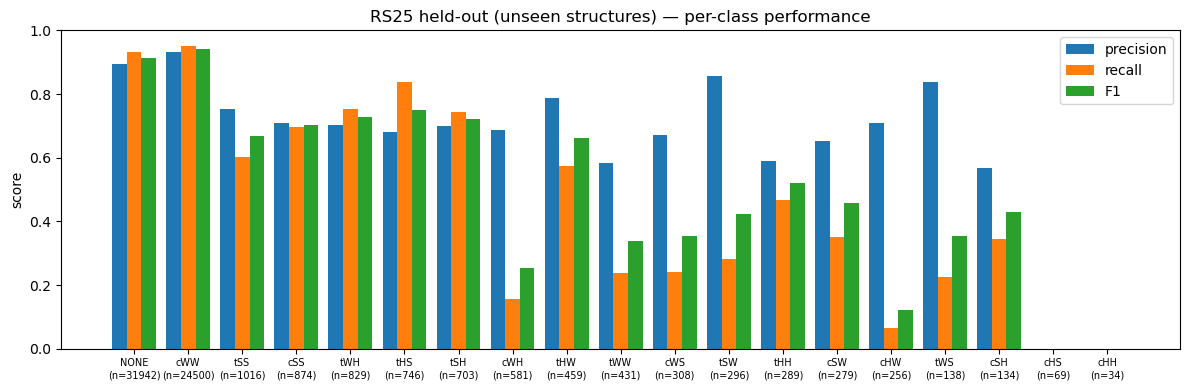

In [12]:
import numpy as np
prec, rec, f1, sup = dt.per_class_prf(conf_rs25)
order = [i for i in np.argsort(-sup.numpy()) if sup[i] > 0]
xs = np.arange(len(order)); w = 0.27
plt.figure(figsize=(12, 4))
plt.bar(xs - w, prec.numpy()[order], w, label='precision')
plt.bar(xs,     rec.numpy()[order],  w, label='recall')
plt.bar(xs + w, f1.numpy()[order],   w, label='F1')
plt.xticks(xs, [f"{class_names[i]}\n(n={int(sup[i])})" for i in order], fontsize=7)
plt.ylabel('score'); plt.ylim(0, 1); plt.legend()
plt.title('RS25 held-out (unseen structures) — per-class performance')
plt.tight_layout(); plt.show()

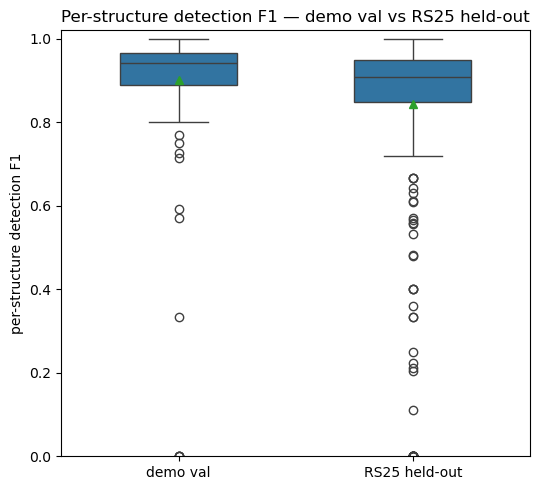

In [13]:
import pandas as pd, seaborn as sns

# distribution of per-structure detection F1 (the aggregate hides the spread / outliers)
val_f1 = dt.per_structure_metrics(dmodel, dval)["det_f1"]
held_f1 = dt.per_structure_metrics(dmodel, held)["det_f1"]
dfb = pd.DataFrame(
    [("demo val", v) for v in val_f1] + [("RS25 held-out", v) for v in held_f1],
    columns=["dataset", "det_f1"])

plt.figure(figsize=(5.5, 5))
ax = sns.boxplot(data=dfb, x="dataset", y="det_f1", width=0.5, showmeans=True,
                 meanprops={"marker": "^", "markerfacecolor": "#2ca02c", "markeredgecolor": "#2ca02c"})
ax.set_ylim(0, 1.02); ax.set_ylabel("per-structure detection F1"); ax.set_xlabel("")
ax.set_title("Per-structure detection F1 — demo val vs RS25 held-out")
plt.tight_layout(); plt.show()